In [39]:
import json
import os

import pandas as pd

# Plot the accuracy 

dir = '../data/results/experiments/clustering_experiment_7'

errors_df = pd.read_csv(os.path.join(dir, 'errors.csv')).drop(columns=['Unnamed: 0'])
complexity_df = pd.read_csv(os.path.join(dir, 'complexity.csv')).drop(columns=['Unnamed: 0'])
runtime_df = pd.read_csv(os.path.join(dir, 'runtime.csv')).drop(columns=['Unnamed: 0'])
with open(os.path.join(dir, 'config.json')) as f:
    config = json.load(f)

print(config)


{'wknn_k': 2, 'rf_param': 'rsrq', 'operator_choice': [1, 10, 50, 88], 'cluster_range': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20], 'n_runs': 10, 'campaigns': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20], 'runtime': 3781.5134892463684}


In [40]:
cluster_columns = [col for col in errors_df.columns]

melted_error_df = pd.melt(errors_df, value_vars=cluster_columns,
                          var_name='clusters', value_name='error')

melted_complexity_df = pd.melt(complexity_df, value_vars=cluster_columns,
                               var_name='clusters', value_name='complexity')

melted_runtime_df = pd.melt(runtime_df, value_vars=cluster_columns, var_name='clusters', value_name='runtime')

melted_complexity_df['complexity'] = melted_complexity_df['complexity'].astype(int)

merged = pd.merge(melted_error_df, melted_complexity_df, on='clusters', how='left')
merged = pd.merge(merged, melted_runtime_df, on='clusters', how='left')

merged

,clusters,error,complexity,runtime
0,1,2.703714,3491616,15.870585
1,1,2.703714,3491616,15.648650
2,1,2.703714,3491616,15.516611
3,1,2.703714,3491616,15.778668
4,1,2.703714,3491616,15.431089
...,...,...,...,...
19995,20,3.654814,226167,8.942342
19996,20,3.654814,226167,8.323000
19997,20,3.654814,226167,8.492955
19998,20,3.654814,226167,7.952321


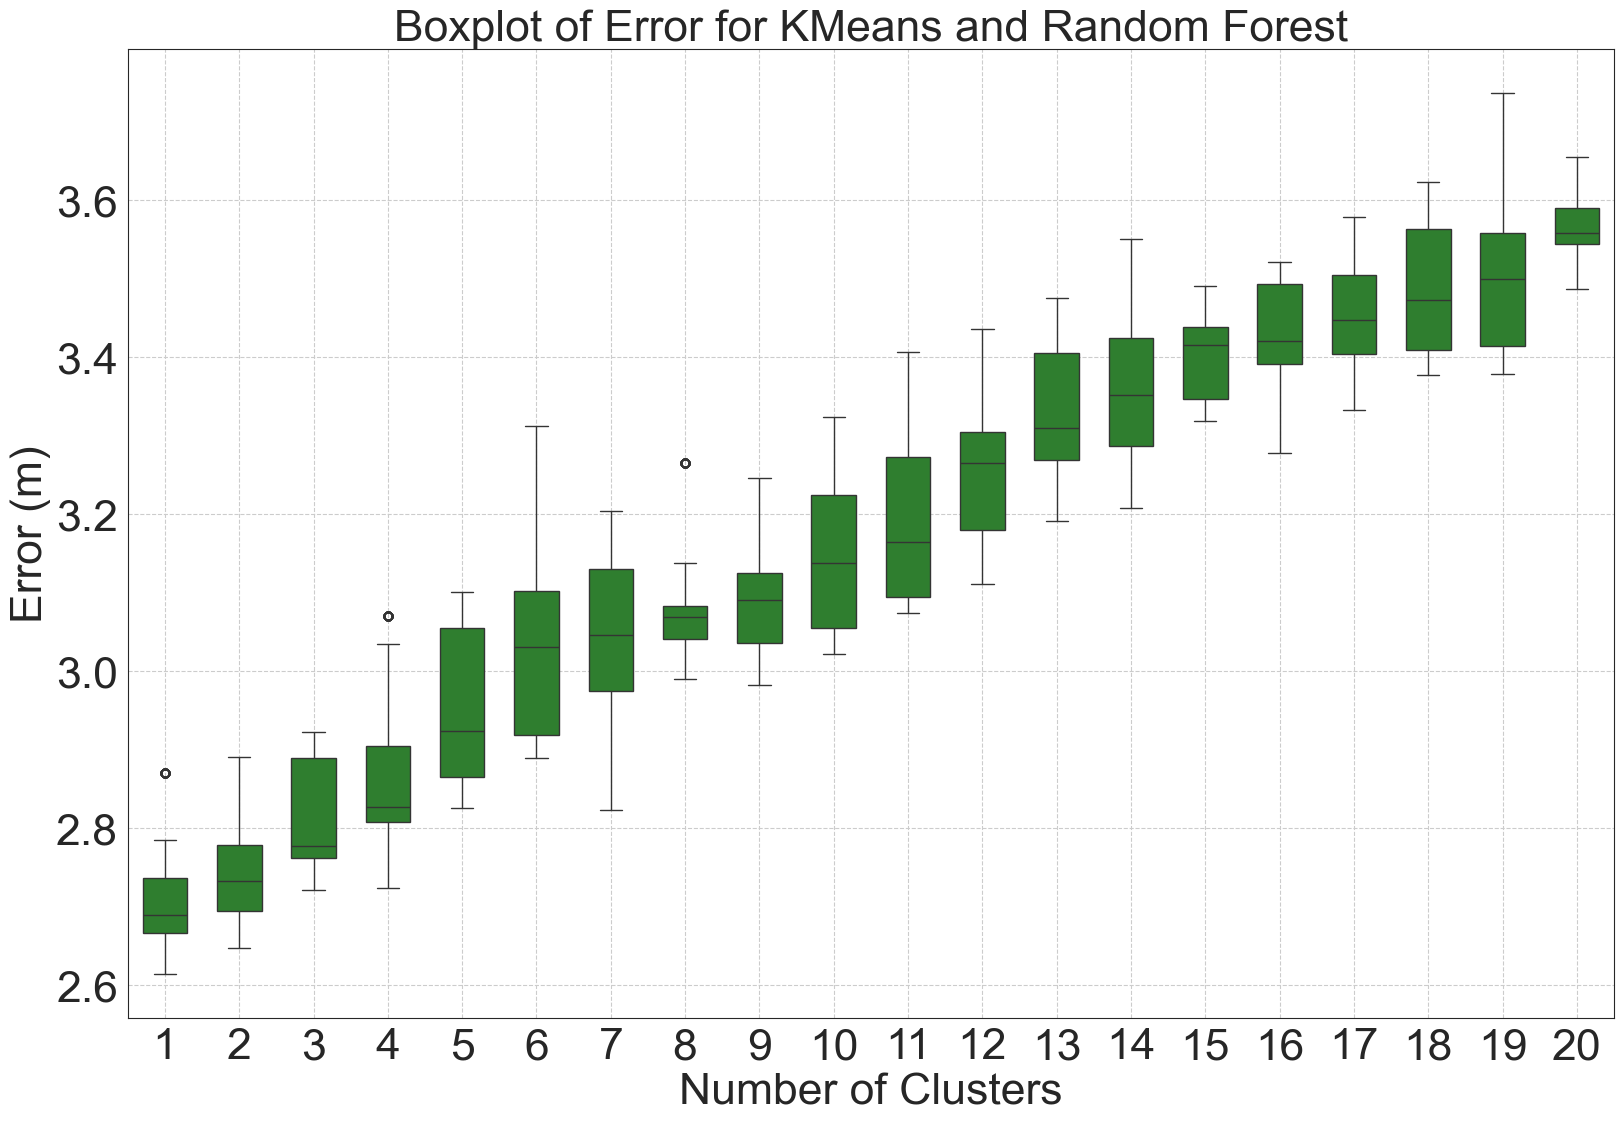

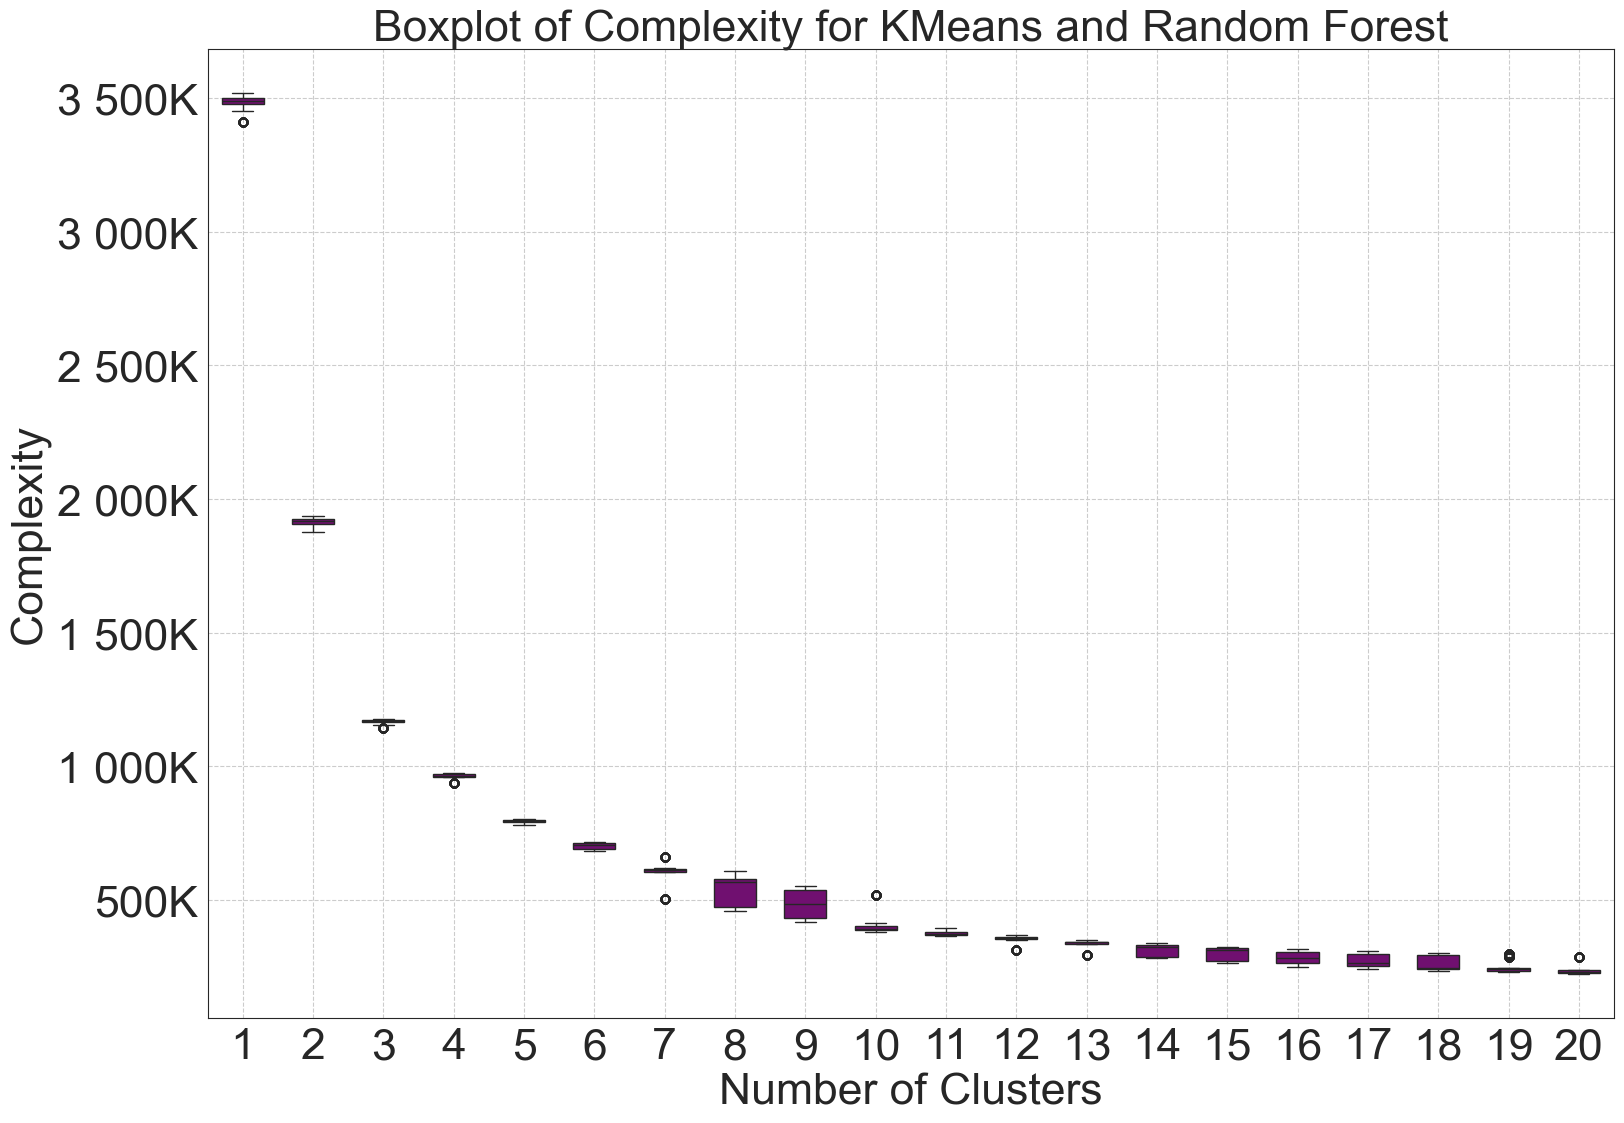

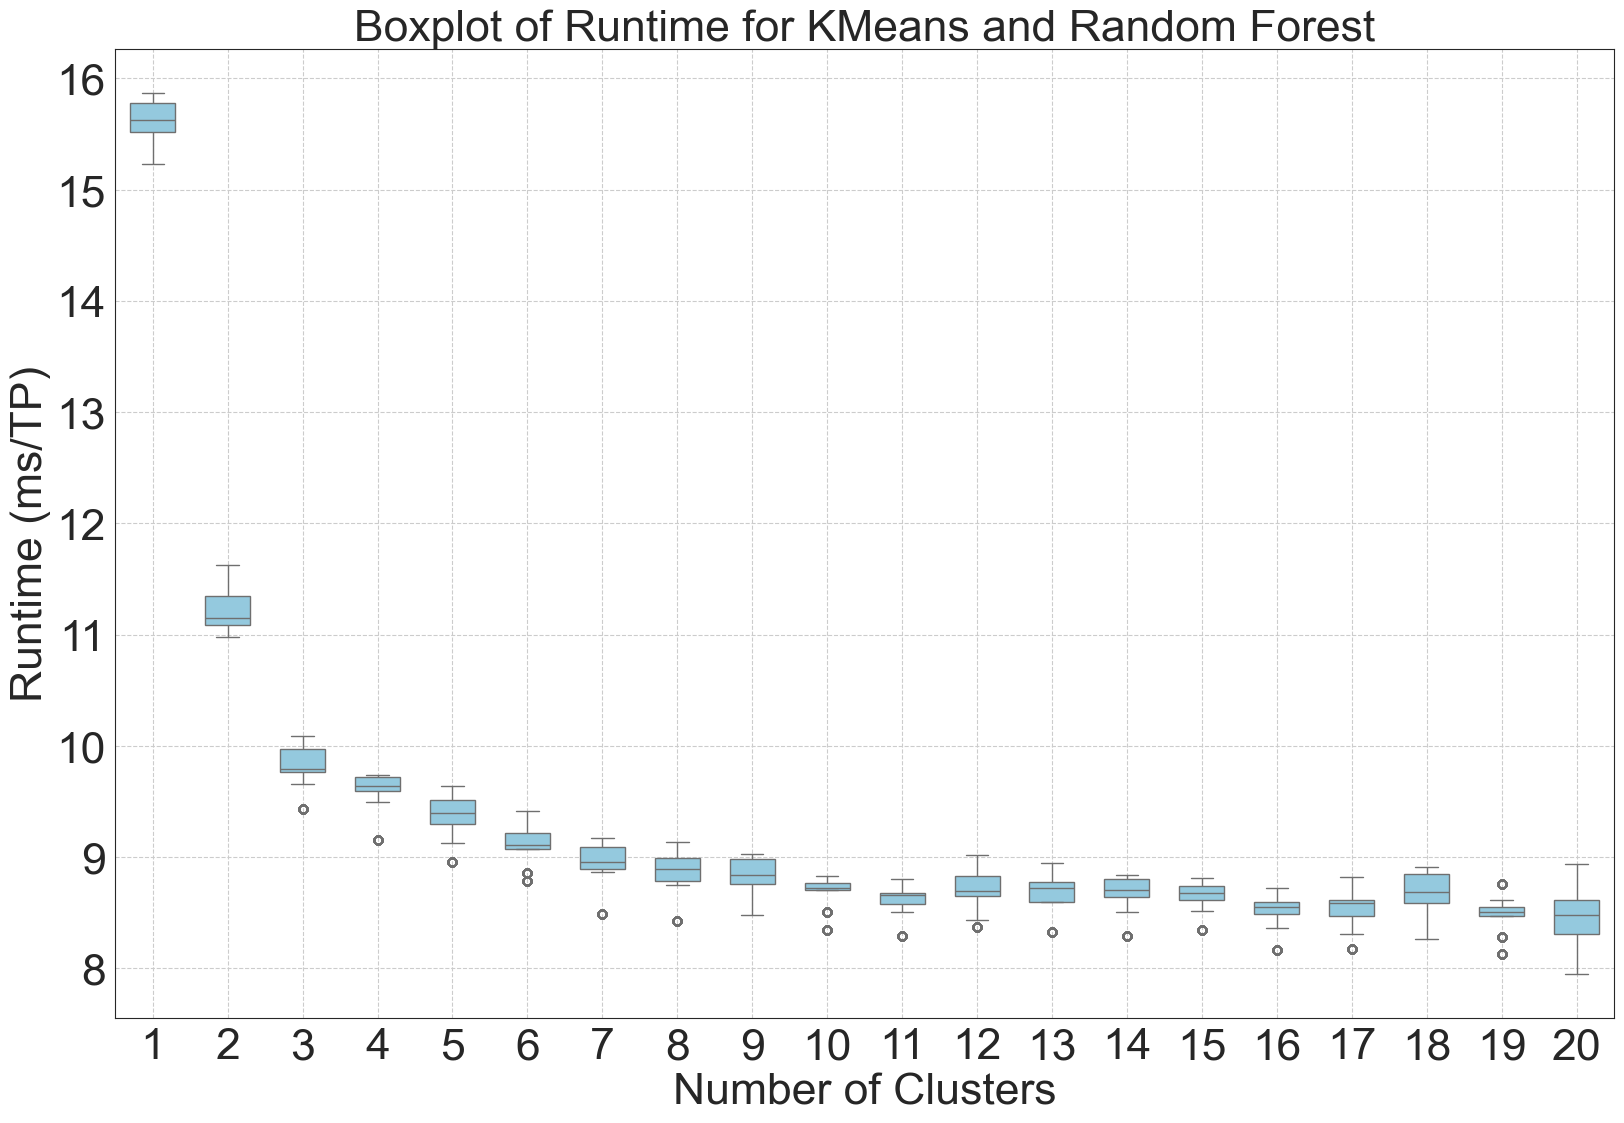

In [50]:
from matplotlib.ticker import FuncFormatter
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({"font.size": 32})


def plot_data(df: pd.DataFrame, x_label: str, y_label: str, x: str, y: str, title: str, color: str):
    # Set the style to white background
    plt.figure(figsize=(17, 12))
    sns.set_style("white")

    # Create the boxplot using seaborn
    sns.boxplot(x=x, y=y, data=df, width=0.6, color=color)

    # Add labels and title
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(title)

    # Remove grid or make it very subtle
    plt.grid(linestyle='--')

    from matplotlib.ticker import FormatStrFormatter

    def thousands_formatter(x, pos):
        return f'{x / 1000:,.0f}K'.replace(',', ' ').replace('.', ',')

    if y == 'complexity':
        plt.gca().yaxis.set_major_formatter(FuncFormatter(thousands_formatter))
    elif y == 'runtime':
        plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
    else:
        plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

    # Show the plot
    plt.tight_layout()
    plt.show()


plot_data(
    df=merged,
    x='clusters',
    y='error',
    x_label='Number of Clusters',
    y_label='Error (m)',
    title='Boxplot of Error for KMeans and Random Forest',
    color='forestgreen'
)

plot_data(
    df=merged,
    x='clusters',
    y='complexity',
    x_label='Number of Clusters',
    y_label='Complexity',
    title='Boxplot of Complexity for KMeans and Random Forest',
    color='purple'
)

plot_data(
    df=merged,
    x='clusters',
    y='runtime',
    x_label='Number of Clusters',
    y_label='Runtime (ms/TP)',
    title='Boxplot of Runtime for KMeans and Random Forest',
    color='skyblue'
)


In [67]:
means = merged.groupby('clusters')['runtime'].mean()

r2 = (means['1'] - means['2']) / means['1'] * 100
d2 = means['1'] - means['2']
print(r2, d2)

r20 = (means['1'] - means['20']) / means['1'] * 100
d20 = means['1'] - means['20']
print(r20, d20)

r10 = (means['1'] - means['10']) / means['1'] * 100
d10 = means['1'] - means['10']
print(r10, d10)

28.167061959200506 4.39761705800408
45.80576835719861 7.151481704921052
44.36007517915999 6.925771086270387
